In [1]:
# %% [markdown]
# # Glioma Grading with Proper Train/Val/Test Split and Explainable AI Components
# 
# This notebook follows best practices:
# 1. Split TCGA **before** any synthetic generation.
# 2. Balance **only the training set** using CTGAN.
# 3. Use validation set for early stopping.
# 4. Evaluate on held‑out test set and external CGGA.
# 5. Visualise all results.

# Cell 1: Imports and Hardware Setup
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve          # <-- corrected import
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear, to_hetero

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [2]:
# %% [markdown]
# ## 2. Load Data and Define Feature Columns

# %%
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data loaded.")
print("TCGA shape:", tcga_df.shape)
print("CGGA shape:", cgga_df.shape)

Data loaded.
TCGA shape: (839, 24)
CGGA shape: (286, 24)


In [3]:
# %% [markdown]
# ## 3. Stratified Split of TCGA into Train/Val/Test (70/15/15)

# %%
# First split: separate training (70%) from temp (30%)
train_df, temp_df = train_test_split(
    tcga_df, 
    test_size=0.3, 
    stratify=tcga_df['Grade'], 
    random_state=42
)

# Second split: divide temp equally into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    stratify=temp_df['Grade'], 
    random_state=42
)

print(f"Train size (original): {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
print("\nClass distribution in training set (before balancing):")
print(train_df['Grade'].value_counts())


Train size (original): 587
Validation size: 126
Test size: 126

Class distribution in training set (before balancing):
Grade
0    341
1    246
Name: count, dtype: int64


In [4]:
# %% [markdown]
# ## 4. Balance ONLY the Training Set with CTGAN

# %%
# Metadata for CTGAN
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

# Determine how many minority samples to add
class_counts = train_df['Grade'].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
samples_needed = class_counts[majority_class] - class_counts[minority_class]

print(f"Generating {samples_needed} synthetic minority samples for training...")

# Fit CTGAN only on training data
synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(train_df)

# Generate only minority-class samples
condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[condition])

# Create balanced training set
train_balanced_df = pd.concat([train_df, synthetic_samples], ignore_index=True)

print("Training set balanced.")
print("New class distribution:")
print(train_balanced_df['Grade'].value_counts())

Generating 95 synthetic minority samples for training...


Sampling conditions: 100%|██████████| 95/95 [00:00<00:00, 474.12it/s]

Training set balanced.
New class distribution:
Grade
1    341
0    341
Name: count, dtype: int64


In [5]:
# %% [markdown]
# ## 5. Graph Construction Function (with reverse edges) – FIXED

# %%
def construct_bipartite_heterograph(df):
    """Build a heterogeneous graph with Patient and Gene nodes, including reverse edges."""
    graph = HeteroData()
    
    # Patient features: Gender, Race, Age (normalized)
    scaler = StandardScaler()
    age_norm = scaler.fit_transform(df[['Age_at_diagnosis']])
    patient_feats = np.hstack([df[['Gender', 'Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(patient_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    # Gene nodes: one‑hot identity
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    # Edge lists (Gene -> Patient)
    src_genes, dst_patients = [], []
    # Use enumerate to get contiguous patient index 0..N-1
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)   # now p_idx is guaranteed sequential
    
    # Forward edges (Gene -> Patient)
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    # Reverse edges (Patient -> Gene)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    
    return graph

In [6]:
# %% [markdown]
# ## 6. Build Graphs for Train, Val, Test, and CGGA

# %%
tcga_train_graph = construct_bipartite_heterograph(train_balanced_df).to(device)
tcga_val_graph   = construct_bipartite_heterograph(val_df).to(device)
tcga_test_graph  = construct_bipartite_heterograph(test_df).to(device)
cgga_graph       = construct_bipartite_heterograph(cgga_df).to(device)

print("Graphs built and moved to device.")
print(f"Train patients: {tcga_train_graph['Patient'].x.shape[0]}")
print(f"Val patients:   {tcga_val_graph['Patient'].x.shape[0]}")
print(f"Test patients:  {tcga_test_graph['Patient'].x.shape[0]}")
print(f"CGGA patients:  {cgga_graph['Patient'].x.shape[0]}")

Graphs built and moved to device.
Train patients: 682
Val patients:   126
Test patients:  126
CGGA patients:  286


In [7]:
# %% [markdown]
# ## 7. Define the GNN Model (Heterogeneous GATv2)

# %%
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        
        # Initial linear projections for each node type (lazy layers)
        self.patient_lin = Linear(-1, hidden_dim)
        self.gene_lin = Linear(-1, hidden_dim)
        
        # Relation‑specific GAT layers (we have two relations: mutates and mutated_by)
        self.conv_gene_to_patient = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.conv_patient_to_gene = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        
        # Skip connections
        self.patient_skip = Linear(hidden_dim, hidden_dim)
        self.gene_skip = Linear(hidden_dim, hidden_dim)
        
        # Final classifier (only on patient nodes)
        self.classifier = Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        # Initial transformation
        h_patient = F.relu(self.patient_lin(x_dict['Patient']))
        h_gene = F.relu(self.gene_lin(x_dict['Gene']))
        
        # Gene -> Patient message passing
        out_patient = self.conv_gene_to_patient((h_gene, h_patient), edge_index_dict[('Gene', 'mutates', 'Patient')])
        
        # Patient -> Gene message passing (reverse)
        out_gene = self.conv_patient_to_gene((h_patient, h_gene), edge_index_dict[('Patient', 'mutated_by', 'Gene')])
        
        # Skip connections
        h_patient = self.patient_skip(h_patient) + out_patient
        h_gene = self.gene_skip(h_gene) + out_gene
        
        # Activation and dropout
        h_patient = F.dropout(F.leaky_relu(h_patient, 0.2), self.dropout, training=self.training)
        h_gene = F.dropout(F.leaky_relu(h_gene, 0.2), self.dropout, training=self.training)
        
        # Return logits for patient nodes only
        return self.classifier(h_patient)

# Instantiate model
model = HeteroGATv2(hidden_dim=32, out_dim=2, num_heads=8).to(device)

# ✅ Dummy forward pass to initialize lazy layers (requires a graph)
with torch.no_grad():
    _ = model(tcga_train_graph.x_dict, tcga_train_graph.edge_index_dict)

# Now count parameters (all initialized)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters.")

Model has 37346 parameters.


In [8]:
# %% [markdown]
# ## 8. Define Loss Functions (Focal Loss + Class Weights)

# %%
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights based on original training imbalance (before balancing)
original_counts = train_df['Grade'].value_counts()
majority = original_counts.idxmax()
minority = original_counts.idxmin()
penalty = original_counts[majority] / original_counts[minority]
class_weights = torch.tensor([1.0, penalty], dtype=torch.float).to(device)

# Choose your loss: standard weighted CE or Focal Loss
# criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

In [9]:
# %% [markdown]
# ## 9. Training Loop with Validation and Early Stopping (Debug Version)

# %%
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'   # Force synchronous CUDA execution for precise error location

epochs = 200
patience = 20
best_val_auc = 0
patience_counter = 0
best_model_state = None

train_losses = []
val_aucs = []

# Verify edge indices are valid
def check_edge_indices(graph, name):
    for key, edge_idx in graph.edge_index_dict.items():
        if edge_idx.numel() == 0:
            print(f"Warning: {name} has empty edge index for {key}")
            continue
        src, dst = edge_idx
        if key[0] == 'Gene' and key[2] == 'Patient':
            max_src = src.max().item()
            max_dst = dst.max().item()
            num_genes = graph['Gene'].x.shape[0]
            num_patients = graph['Patient'].x.shape[0]
            assert max_src < num_genes, f"{name}: Gene index {max_src} out of range (max {num_genes-1})"
            assert max_dst < num_patients, f"{name}: Patient index {max_dst} out of range (max {num_patients-1})"
        elif key[0] == 'Patient' and key[2] == 'Gene':
            max_src = src.max().item()
            max_dst = dst.max().item()
            num_patients = graph['Patient'].x.shape[0]
            num_genes = graph['Gene'].x.shape[0]
            assert max_src < num_patients, f"{name}: Patient index {max_src} out of range"
            assert max_dst < num_genes, f"{name}: Gene index {max_dst} out of range"

print("Checking graph validity...")
check_edge_indices(tcga_train_graph, "Train")
check_edge_indices(tcga_val_graph, "Validation")
print("Graph checks passed.")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    out = model(tcga_train_graph.x_dict, tcga_train_graph.edge_index_dict)
    loss = criterion(out, tcga_train_graph['Patient'].y)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_out = model(tcga_val_graph.x_dict, tcga_val_graph.edge_index_dict)
        
        # Debug: check for NaNs/Infs in output
        if torch.isnan(val_out).any() or torch.isinf(val_out).any():
            print(f"Epoch {epoch+1}: val_out contains NaNs/Infs!")
            break
        
        val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
        val_labels = tcga_val_graph['Patient'].y.cpu().numpy()
        
        # Check probability range
        if (val_probs < 0).any() or (val_probs > 1).any():
            print(f"Epoch {epoch+1}: val_probs out of [0,1] range")
            break
        
        val_auc = roc_auc_score(val_labels, val_probs)
        val_aucs.append(val_auc)
    
    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Val AUC: {val_auc:.4f}")

# Restore best model
model.load_state_dict(best_model_state)
model = model.to(device)
print(f"\nBest validation AUC: {best_val_auc:.4f}")

# Reset environment variable if desired (optional)
# os.environ.pop('CUDA_LAUNCH_BLOCKING', None)

Checking graph validity...
Graph checks passed.
Epoch  10 | Loss: 0.2215 | Val AUC: 0.7596
Epoch  20 | Loss: 0.2023 | Val AUC: 0.7860
Epoch  30 | Loss: 0.1989 | Val AUC: 0.8030
Epoch  40 | Loss: 0.1946 | Val AUC: 0.8206
Epoch  50 | Loss: 0.1861 | Val AUC: 0.8403
Epoch  60 | Loss: 0.1805 | Val AUC: 0.8506
Epoch  70 | Loss: 0.1796 | Val AUC: 0.8604
Epoch  80 | Loss: 0.1730 | Val AUC: 0.8726
Epoch  90 | Loss: 0.1718 | Val AUC: 0.8811
Epoch 100 | Loss: 0.1640 | Val AUC: 0.8894
Epoch 110 | Loss: 0.1688 | Val AUC: 0.8930
Epoch 120 | Loss: 0.1658 | Val AUC: 0.8974
Epoch 130 | Loss: 0.1596 | Val AUC: 0.8995
Epoch 140 | Loss: 0.1603 | Val AUC: 0.9013
Epoch 150 | Loss: 0.1552 | Val AUC: 0.9026
Epoch 160 | Loss: 0.1552 | Val AUC: 0.9031
Epoch 170 | Loss: 0.1552 | Val AUC: 0.9041
Epoch 180 | Loss: 0.1542 | Val AUC: 0.9057
Epoch 190 | Loss: 0.1544 | Val AUC: 0.9062
Epoch 200 | Loss: 0.1597 | Val AUC: 0.9075

Best validation AUC: 0.9075


FINAL EVALUATION
TCGA Test   - Acc: 0.7857, AUC: 0.9020
CGGA        - Acc: 0.4720, AUC: 0.8065


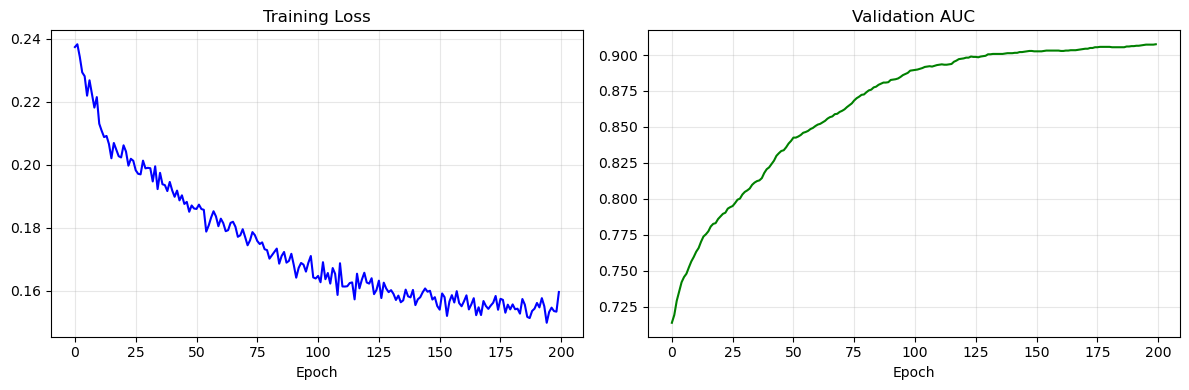

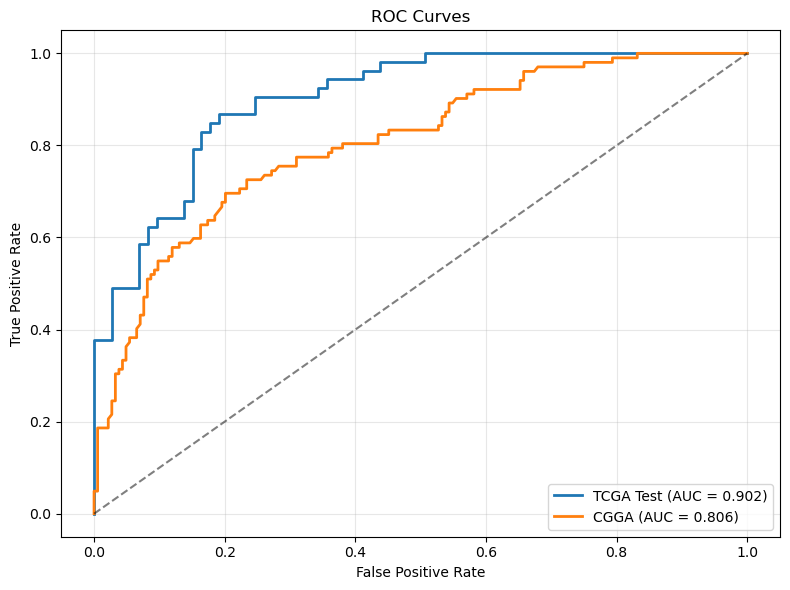

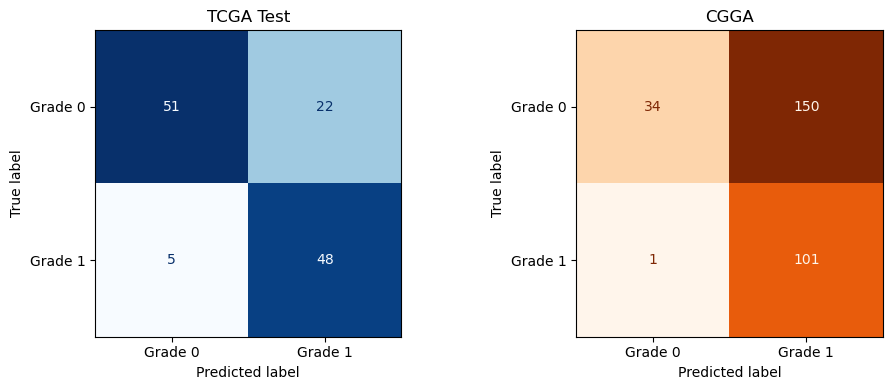

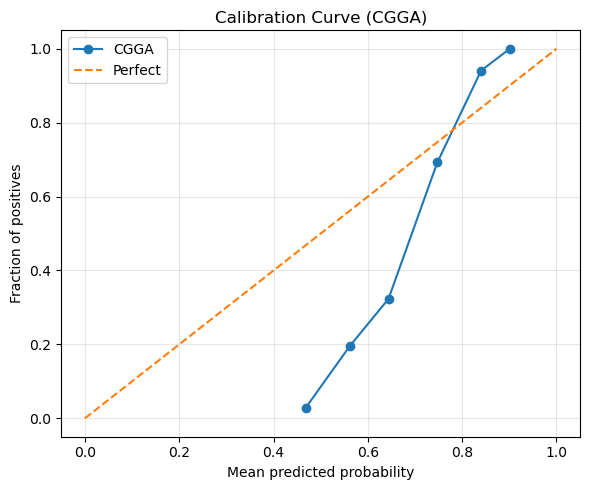

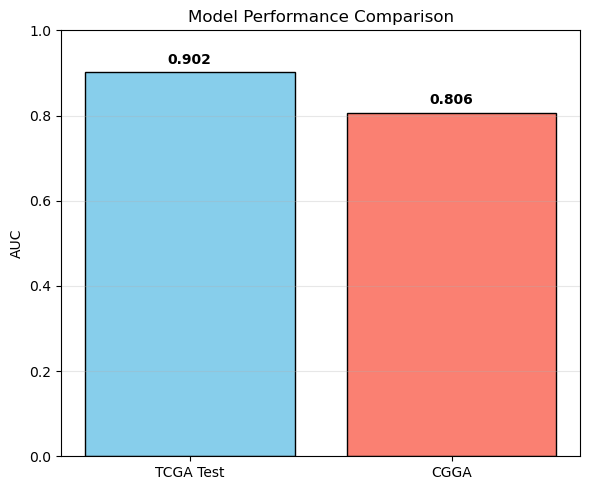

In [10]:

# %% [markdown]
# ## 10. Final Evaluation on TCGA Test Set and CGGA

# %%
model.eval()
with torch.no_grad():
    # TCGA test
    test_out = model(tcga_test_graph.x_dict, tcga_test_graph.edge_index_dict)
    test_probs = F.softmax(test_out, dim=1).cpu().numpy()
    test_labels = tcga_test_graph['Patient'].y.cpu().numpy()
    test_auc = roc_auc_score(test_labels, test_probs[:, 1])
    test_preds = test_out.argmax(dim=1).cpu().numpy()
    test_acc = (test_preds == test_labels).mean()
    
    # CGGA
    cgga_out = model(cgga_graph.x_dict, cgga_graph.edge_index_dict)
    cgga_probs = F.softmax(cgga_out, dim=1).cpu().numpy()
    cgga_labels = cgga_graph['Patient'].y.cpu().numpy()
    cgga_auc = roc_auc_score(cgga_labels, cgga_probs[:, 1])
    cgga_preds = cgga_out.argmax(dim=1).cpu().numpy()
    cgga_acc = (cgga_preds == cgga_labels).mean()

print("="*50)
print("FINAL EVALUATION")
print("="*50)
print(f"TCGA Test   - Acc: {test_acc:.4f}, AUC: {test_auc:.4f}")
print(f"CGGA        - Acc: {cgga_acc:.4f}, AUC: {cgga_auc:.4f}")
print("="*50)

# %% [markdown]
# ## 11. Visualizations

# %%
# 11.1 Training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(train_losses, color='blue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(val_aucs, color='green')
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11.2 ROC Curves
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs[:, 1])
fpr_cgga, tpr_cgga, _ = roc_curve(cgga_labels, cgga_probs[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr_test, tpr_test, label=f'TCGA Test (AUC = {test_auc:.3f})', linewidth=2)
plt.plot(fpr_cgga, tpr_cgga, label=f'CGGA (AUC = {cgga_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11.3 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
# TCGA test
cm_test = confusion_matrix(test_labels, test_preds)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=['Grade 0', 'Grade 1'])
disp_test.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('TCGA Test')
# CGGA
cm_cgga = confusion_matrix(cgga_labels, cgga_preds)
disp_cgga = ConfusionMatrixDisplay(cm_cgga, display_labels=['Grade 0', 'Grade 1'])
disp_cgga.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('CGGA')
plt.tight_layout()
plt.show()

# 11.4 Calibration Curve (for CGGA)
fraction_positive, mean_predicted = calibration_curve(cgga_labels, cgga_probs[:, 1], n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(mean_predicted, fraction_positive, marker='o', label='CGGA')
plt.plot([0,1], [0,1], '--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (CGGA)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11.5 AUC Comparison Bar Chart
plt.figure(figsize=(6,5))
bars = plt.bar(['TCGA Test', 'CGGA'], [test_auc, cgga_auc], color=['skyblue', 'salmon'], edgecolor='black')
plt.ylim(0,1)
plt.ylabel('AUC')
plt.title('Model Performance Comparison')
for bar, val in zip(bars, [test_auc, cgga_auc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 12. (Optional) Save Best Model

# %%
# torch.save(best_model_state, 'best_glioma_model.pth')
# print("Model saved.")